In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

import pandas as pd
import torch

from vis import (
    Plotter,
    _window_and_filter,
    load_embeddings_pt,
    centroids_by_token,
)

from utils import (
    load_graph_from_txt, 
    dirichlet_energy_laplacian, 
    compute_rule_following_accuracy_over_records, 

    )

In [2]:
EMB_DIR     = Path("../embeddings/numbers/grid_numbers")
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/grid_numbers/grid_structure.txt")



hp_grid = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

Grid - #nodi: 15 #archi: 22


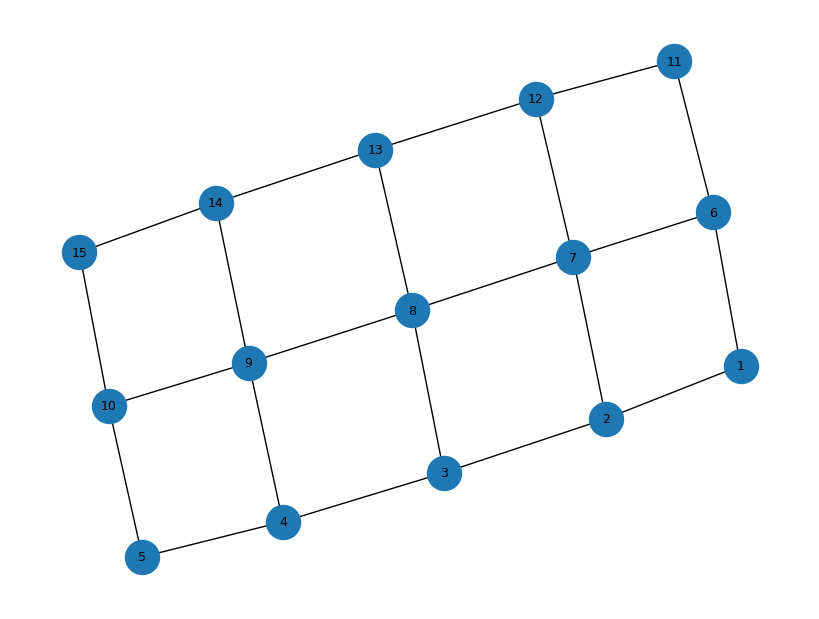

In [3]:

G = load_graph_from_txt(STRUCT_PATH, kind="grid")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=0)  
nx.draw(
    G, pos,
    with_labels=True,
    node_size=600,
    font_size=9
)
plt.show()

In [4]:
from sklearn.decomposition import PCA

ctx = 2000
WIN = 100
PCA_K = 2
MIN_NODES = PCA_K + 1

all_results = []

pt_path = EMB_DIR / f"reprs_grid_numbers_one_rw_2000_line000000_layer31.pt"
ids_np, emb_np = load_embeddings_pt(pt_path)

T_file = len(ids_np)
t_end_ref = min(ctx, T_file)

CONTEXT_LENS = list(range(WIN, t_end_ref + 1, WIN))
if CONTEXT_LENS[-1] != t_end_ref:
    CONTEXT_LENS.append(t_end_ref)

graph_nodes = list(G.nodes())

print(f"\n=== CTX={ctx} | file_len={T_file} | t_end_ref={t_end_ref} ===")

for win_len in CONTEXT_LENS:
    t0 = 0#max(0, t_end_ref - win_len)
    t1 = min(win_len, T_file)#t_end_ref

    filtered_ids, filtered_emb = _window_and_filter(
        ids_np, emb_np, hp_grid.id_to_word,
        k=50,
        t_start=t0, t_end=t1,
        title=f"ctx={ctx}, win_len={win_len}, local=[{t0}:{t1})"
    )

    if len(filtered_ids) == 0:
        all_results.append({
            "ctx": ctx, "context_len": win_len,
            "t_start_local": t0, "t_end_local": t1,
            "energy": np.nan, "energy_per_edge": np.nan,
            "n_filtered": 0, "n_centroids": 0,
            "n_common": 0, "n_edges_subgraph": 0,
        })
        continue

    centroid_ids, centroids = centroids_by_token(filtered_ids, filtered_emb)

    if len(centroid_ids) == 0:
        all_results.append({
            "ctx": ctx, "context_len": win_len,
            "t_start_local": t0, "t_end_local": t1,
            "energy": np.nan, "energy_per_edge": np.nan,
            "n_filtered": len(filtered_ids), "n_centroids": 0,
            "n_common": 0, "n_edges_subgraph": 0,
        })
        continue

    labels = [hp_grid.id_to_word.get(int(t), str(int(t))) for t in centroid_ids]
    idx = {lab: i for i, lab in enumerate(labels)}
    common = [node for node in graph_nodes if node in idx]

    if len(common) < MIN_NODES:
        E = E_per_edge = np.nan
        m = 0
    else:
        X_common = np.stack([centroids[idx[lab]] for lab in common], axis=0).astype(np.float64)
        X_common = X_common - X_common.mean(axis=0, keepdims=True)

        k = min(PCA_K, len(common) - 1)
        pca = PCA(n_components=k)
        X_pca = pca.fit_transform(X_common)

        G_sub = G.subgraph(common).copy()
        m = G_sub.number_of_edges()

        if m == 0:
            E = E_per_edge = np.nan
        else:
            E = dirichlet_energy_laplacian(G_sub, common, X_pca)
            E_per_edge = E / m

    print(f"  CTX={ctx} | win_len={win_len} | local=[{t0}:{t1}) | E={E}")

    all_results.append({
        "ctx": ctx, "context_len": win_len,
        "t_start_local": t0, "t_end_local": t1,
        "energy": E, "energy_per_edge": E_per_edge,
        "n_filtered": len(filtered_ids), "n_centroids": len(centroid_ids),
        "n_common": len(common), "n_edges_subgraph": m,
    })


=== CTX=2000 | file_len=4000 | t_end_ref=2000 ===
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '15' has only 1 occurrences in [0:100] (requested 50)
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '11' has only 1 occurrences in [0:100] (requested 50)
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '13' has only 3 occurrences in [0:100] (requested 50)
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '12' has only 3 occurrences in [0:100] (requested 50)
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '14' has only 1 occurrences in [0:100] (requested 50)
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '1' has only 3 occurrences in [0:100] (requested 50)
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '2' has only 6 occurrences in [0:100] (requested 50)
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '3' has only 6 occurrences in [0:100] (requested 50)
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '4' has only 7 o

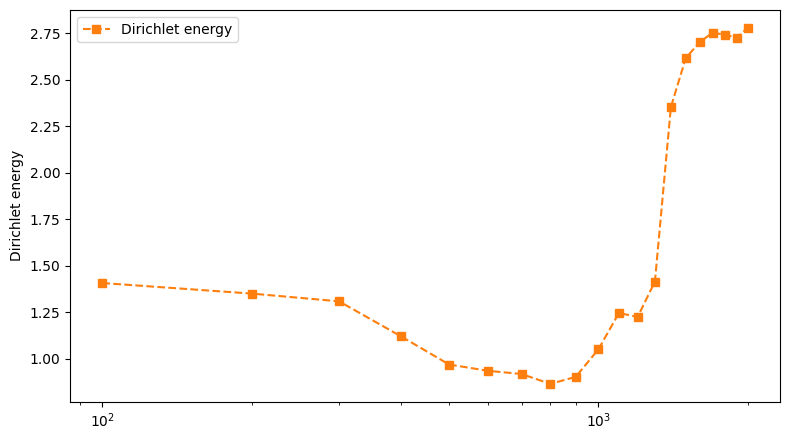

In [6]:
df = pd.DataFrame(all_results)
df_plot = df.dropna(subset=["energy"]).copy().sort_values("context_len")

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(
    df_plot["context_len"], df_plot["energy"],
    marker="s", linestyle="--", color="tab:orange", label="Dirichlet energy"
)
ax.set_ylabel("Dirichlet energy")
plt.xscale("log")

lines1, labels1 = ax.get_legend_handles_labels()
ax.legend(lines1, labels1, loc="best")
plt.tight_layout()
plt.show()

Grid - #nodi: 15 #archi: 22


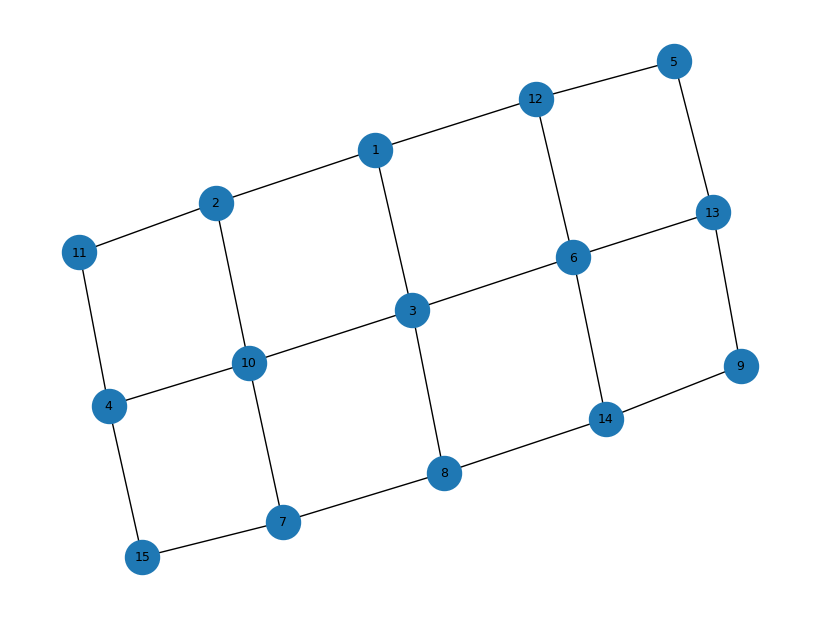

In [37]:
EMB_DIR     = Path("../embeddings/numbers/shuffled_grid_numbers")
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/shuffled_grid_numbers/grid_structure.txt")

hp_gid_shuffled = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)
G = load_graph_from_txt(STRUCT_PATH, kind="grid")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=0)  
nx.draw(
    G, pos,
    with_labels=True,
    node_size=600,
    font_size=9
)
plt.show()


=== CTX=2000 | file_len=4000 | t_end_ref=2000 ===
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '15' has only 2 occurrences in [0:100] (requested 50)
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '11' has only 1 occurrences in [0:100] (requested 50)
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '13' has only 3 occurrences in [0:100] (requested 50)
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '12' has only 3 occurrences in [0:100] (requested 50)
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '14' has only 6 occurrences in [0:100] (requested 50)
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '1' has only 3 occurrences in [0:100] (requested 50)
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '2' has only 1 occurrences in [0:100] (requested 50)
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '3' has only 3 occurrences in [0:100] (requested 50)
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '4' has only 2 o

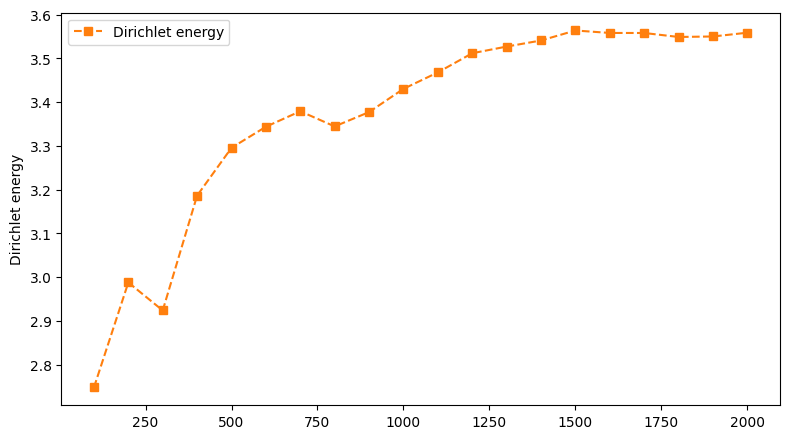

In [ ]:


ctx = 2000
WIN = 100
PCA_K = 2
MIN_NODES = PCA_K + 1

all_results = []

pt_path = EMB_DIR / f"reprs_grid_numbers_shuffled_one_rw_2000_line000000_layer31.pt"
ids_np, emb_np = load_embeddings_pt(pt_path)

T_file = len(ids_np)
t_end_ref = min(ctx, T_file)

CONTEXT_LENS = list(range(WIN, t_end_ref + 1, WIN))
if CONTEXT_LENS[-1] != t_end_ref:
    CONTEXT_LENS.append(t_end_ref)

graph_nodes = list(G.nodes())

print(f"\n=== CTX={ctx} | file_len={T_file} | t_end_ref={t_end_ref} ===")

for win_len in CONTEXT_LENS:
    t0 = 0#max(0, t_end_ref - win_len)
    t1 = min(win_len, T_file)#t_end_ref

    filtered_ids, filtered_emb = _window_and_filter(
        ids_np, emb_np, hp_grid.id_to_word,
        k=50,
        t_start=t0, t_end=t1,
        title=f"ctx={ctx}, win_len={win_len}, local=[{t0}:{t1})"
    )

    if len(filtered_ids) == 0:
        all_results.append({
            "ctx": ctx, "context_len": win_len,
            "t_start_local": t0, "t_end_local": t1,
            "energy": np.nan, "energy_per_edge": np.nan,
            "n_filtered": 0, "n_centroids": 0,
            "n_common": 0, "n_edges_subgraph": 0,
        })
        continue

    centroid_ids, centroids = centroids_by_token(filtered_ids, filtered_emb)

    if len(centroid_ids) == 0:
        all_results.append({
            "ctx": ctx, "context_len": win_len,
            "t_start_local": t0, "t_end_local": t1,
            "energy": np.nan, "energy_per_edge": np.nan,
            "n_filtered": len(filtered_ids), "n_centroids": 0,
            "n_common": 0, "n_edges_subgraph": 0,
        })
        continue

    labels = [hp_grid.id_to_word.get(int(t), str(int(t))) for t in centroid_ids]
    idx = {lab: i for i, lab in enumerate(labels)}
    common = [node for node in graph_nodes if node in idx]

    if len(common) < MIN_NODES:
        E = E_per_edge = np.nan
        m = 0
    else:
        X_common = np.stack([centroids[idx[lab]] for lab in common], axis=0).astype(np.float64)
        X_common = X_common - X_common.mean(axis=0, keepdims=True)

        k = min(PCA_K, len(common) - 1)
        pca = PCA(n_components=k)
        X_pca = pca.fit_transform(X_common)

        G_sub = G.subgraph(common).copy()
        m = G_sub.number_of_edges()

        if m == 0:
            E = E_per_edge = np.nan
        else:
            E = dirichlet_energy_laplacian(G_sub, common, X_pca)
            E_per_edge = E / m

    print(f"  CTX={ctx} | win_len={win_len} | local=[{t0}:{t1}) | E={E}")

    all_results.append({
        "ctx": ctx, "context_len": win_len,
        "t_start_local": t0, "t_end_local": t1,
        "energy": E, "energy_per_edge": E_per_edge,
        "n_filtered": len(filtered_ids), "n_centroids": len(centroid_ids),
        "n_common": len(common), "n_edges_subgraph": m,
    })

df = pd.DataFrame(all_results)
df_plot = df.dropna(subset=["energy"]).copy().sort_values("context_len")

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(
    df_plot["context_len"], df_plot["energy"],
    marker="s", linestyle="--", color="tab:orange", label="Dirichlet energy"
)
ax.set_ylabel("Dirichlet energy")


lines1, labels1 = ax.get_legend_handles_labels()
ax.legend(lines1, labels1, loc="best")
plt.tight_layout()
plt.show()

# Paper Grid

In [ ]:
VOCAB_PATH = Path("../data/paper-tkid-map.txt")
grid_folder = "paper_grid"
structure_name = "paper_grid"

EMB_DIR    = Path(f"../embeddings/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="grid")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=0)  
nx.draw(
    G, pos,
    with_labels=True,
    node_size=600,
    font_size=9
)
plt.show()

In [ ]:
from sklearn.decomposition import PCA

ctx = 3000
WIN = 300
PCA_K = 10
MIN_NODES = PCA_K + 1

all_results = []

pt_path = EMB_DIR / f"reprs_{structure_name}_one_rw_{ctx}_line000000_layer31.pt"
ids_np, emb_np = load_embeddings_pt(pt_path)

T_file = len(ids_np)
t_end_ref = min(ctx, T_file)

CONTEXT_LENS = list(range(WIN, t_end_ref + 1, WIN))
if CONTEXT_LENS[-1] != t_end_ref:
    CONTEXT_LENS.append(t_end_ref)

graph_nodes = list(G.nodes())

print(f"\n=== CTX={ctx} | file_len={T_file} | t_end_ref={t_end_ref} ===")

for win_len in CONTEXT_LENS:
    t0 = 0#max(0, t_end_ref - win_len)
    t1 = min(win_len, T_file)#t_end_ref

    filtered_ids, filtered_emb = _window_and_filter(
        ids_np, emb_np, hp_grid.id_to_word,
        k=50,
        t_start=t0, t_end=t1,
        title=f"ctx={ctx}, win_len={win_len}, local=[{t0}:{t1})"
    )

    if len(filtered_ids) == 0:
        all_results.append({
            "ctx": ctx, "context_len": win_len,
            "t_start_local": t0, "t_end_local": t1,
            "energy": np.nan, "energy_per_edge": np.nan,
            "n_filtered": 0, "n_centroids": 0,
            "n_common": 0, "n_edges_subgraph": 0,
        })
        continue

    centroid_ids, centroids = centroids_by_token(filtered_ids, filtered_emb)

    if len(centroid_ids) == 0:
        all_results.append({
            "ctx": ctx, "context_len": win_len,
            "t_start_local": t0, "t_end_local": t1,
            "energy": np.nan, "energy_per_edge": np.nan,
            "n_filtered": len(filtered_ids), "n_centroids": 0,
            "n_common": 0, "n_edges_subgraph": 0,
        })
        continue

    labels = [hp_grid.id_to_word.get(int(t), str(int(t))) for t in centroid_ids]
    idx = {lab: i for i, lab in enumerate(labels)}
    common = [node for node in graph_nodes if node in idx]

    if len(common) < MIN_NODES:
        E = E_per_edge = np.nan
        m = 0
    else:
        X_common = np.stack([centroids[idx[lab]] for lab in common], axis=0).astype(np.float64)
        X_common = X_common - X_common.mean(axis=0, keepdims=True)

        k = min(PCA_K, len(common) - 1)
        pca = PCA(n_components=k)
        X_pca = pca.fit_transform(X_common)

        G_sub = G.subgraph(common).copy()
        m = G_sub.number_of_edges()

        if m == 0:
            E = E_per_edge = np.nan
        else:
            E = dirichlet_energy_laplacian(G_sub, common, X_pca)
            E_per_edge = E / m

    print(f"  CTX={ctx} | win_len={win_len} | local=[{t0}:{t1}) | E={E}")

    all_results.append({
        "ctx": ctx, "context_len": win_len,
        "t_start_local": t0, "t_end_local": t1,
        "energy": E, "energy_per_edge": E_per_edge,
        "n_filtered": len(filtered_ids), "n_centroids": len(centroid_ids),
        "n_common": len(common), "n_edges_subgraph": m,
    })

In [ ]:
logit_file = EMB_DIR / f"logit_lens_every100tok_{structure_name}_one_rw_3000_layer31.pt"

# Carica
data = torch.load(logit_file, map_location="cpu")

records = data.get("records", [])

summary, df_rule = compute_rule_following_accuracy_over_records(records, G, lowercase=True)



In [ ]:
df = pd.DataFrame(all_results)
df_plot = df.dropna(subset=["energy"]).copy().sort_values("context_len")

fig, ax1 = plt.subplots(figsize=(8, 4.5))

ax1.plot(
    df_rule["token_position_1based"],
    df_rule["rule_following_mass_topk"],
    marker="o", label="Rule-following mass @k"
)
ax1.set_xlabel("Context length / Token position")
ax1.set_ylabel("Rule-following mass @k")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
ax2.plot(
    df_plot["context_len"], df_plot["energy"],
    marker="s", linestyle="--", color="tab:orange", label="Dirichlet energy"
)
ax2.set_ylabel("Dirichlet energy")

plt.title("Rule-following mass vs Dirichlet energy (Paper Grid)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
plt.tight_layout()
plt.show()

# OUR Grid

In [ ]:
VOCAB_PATH = Path("../data/uncorrelated-words/selected_llama31_layer0.txt")
grid_folder = "grid_16"
structure_name = "grid_dataset"

EMB_DIR    = Path(f"../embeddings/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)


In [ ]:

G = load_graph_from_txt(GRID_PATH, kind="grid")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=0)  # layout automatico
nx.draw(
    G, pos,
    with_labels=True,
    node_size=600,
    font_size=9
)
plt.show()

In [ ]:


ctx = 3000
WIN = 100
PCA_K = 15
MIN_NODES = PCA_K + 1

all_results = []

pt_path = EMB_DIR / f"reprs_{structure_name}_one_rw_{ctx}_line000000_layer31.pt"
ids_np, emb_np = load_embeddings_pt(pt_path)

T_file = len(ids_np)
t_end_ref = min(ctx, T_file)

CONTEXT_LENS = list(range(WIN, t_end_ref + 1, WIN))
if CONTEXT_LENS[-1] != t_end_ref:
    CONTEXT_LENS.append(t_end_ref)

graph_nodes = list(G.nodes())

print(f"\n=== CTX={ctx} | file_len={T_file} | t_end_ref={t_end_ref} ===")

for win_len in CONTEXT_LENS:
    t0 =0# max(0, t_end_ref - win_len)
    t1 = min(win_len, T_file)#t_end_ref

    filtered_ids, filtered_emb = _window_and_filter(
        ids_np, emb_np, hp_grid.id_to_word,
        k=50,
        t_start=t0, t_end=t1,
        title=f"ctx={ctx}, win_len={win_len}, local=[{t0}:{t1})"
    )

    if len(filtered_ids) == 0:
        all_results.append({
            "ctx": ctx, "context_len": win_len,
            "t_start_local": t0, "t_end_local": t1,
            "energy": np.nan, "energy_per_edge": np.nan,
            "n_filtered": 0, "n_centroids": 0,
            "n_common": 0, "n_edges_subgraph": 0,
        })
        continue

    centroid_ids, centroids = centroids_by_token(filtered_ids, filtered_emb)

    if len(centroid_ids) == 0:
        all_results.append({
            "ctx": ctx, "context_len": win_len,
            "t_start_local": t0, "t_end_local": t1,
            "energy": np.nan, "energy_per_edge": np.nan,
            "n_filtered": len(filtered_ids), "n_centroids": 0,
            "n_common": 0, "n_edges_subgraph": 0,
        })
        continue

    labels = [hp_grid.id_to_word.get(int(t), str(int(t))) for t in centroid_ids]
    idx = {lab: i for i, lab in enumerate(labels)}
    common = [node for node in graph_nodes if node in idx]

    if len(common) < MIN_NODES:
        E = E_per_edge = np.nan
        m = 0
    else:
        X_common = np.stack([centroids[idx[lab]] for lab in common], axis=0).astype(np.float64)
        X_common = X_common - X_common.mean(axis=0, keepdims=True)

        k = min(PCA_K, len(common) - 1)
        pca = PCA(n_components=k)
        X_pca = pca.fit_transform(X_common)

        G_sub = G.subgraph(common).copy()
        m = G_sub.number_of_edges()

        if m == 0:
            E = E_per_edge = np.nan
        else:
            E = dirichlet_energy_laplacian(G_sub, common, X_pca)
            E_per_edge = E #/ m

    print(f"  CTX={ctx} | win_len={win_len} | local=[{t0}:{t1}) | E={E}")

    all_results.append({
        "ctx": ctx, "context_len": win_len,
        "t_start_local": t0, "t_end_local": t1,
        "energy": E, "energy_per_edge": E_per_edge,
        "n_filtered": len(filtered_ids), "n_centroids": len(centroid_ids),
        "n_common": len(common), "n_edges_subgraph": m,
    })
logit_file = EMB_DIR / f"logit_lens_every100tok_{structure_name}_one_rw_3000_layer31.pt"

# Carica
data = torch.load(logit_file, map_location="cpu")

records = data.get("records", [])

summary, df_rule = compute_rule_following_accuracy_over_records(records, G, lowercase=True)
df = pd.DataFrame(all_results)
df_plot = df.dropna(subset=["energy"]).copy().sort_values("context_len")

fig, ax1 = plt.subplots(figsize=(8, 4.5))

ax1.plot(
    df_rule["token_position_1based"],
    df_rule["rule_following_mass_topk"],
    marker="o", label="Rule-following mass @k"
)
ax1.set_xlabel("Context length / Token position")
ax1.set_ylabel("Rule-following mass @k")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
ax2.plot(
    df_plot["context_len"], df_plot["energy"],
    marker="s", linestyle="--", color="tab:orange", label="Dirichlet energy"
)
ax2.set_ylabel("Dirichlet energy")

plt.title("Rule-following mass vs Dirichlet energy (Our Grid)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
plt.tight_layout()
plt.show()

# 4 levels tree

In [ ]:
VOCAB_PATH = Path("../data/uncorrelated-words/selected_llama31_layer0.txt")
grid_folder = "tree_4_levels"
structure_name = "bin_tree"

STRUCT_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

EMB_DIR    = Path(f"../embeddings/{grid_folder}/")

hp_tree_das = Plotter(VOCAB_PATH, STRUCT_PATH, EMB_DIR)

G = load_graph_from_txt(STRUCT_PATH, kind="tree")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=0)  # layout automatico
nx.draw(
    G, pos,
    with_labels=True,
    node_size=300,
    font_size=9
)
plt.show()


In [ ]:
from sklearn.decomposition import PCA

ctx = 3000
WIN = 300
PCA_K = 10
MIN_NODES = PCA_K + 1

all_results = []
explained_ratios = []

pt_path = EMB_DIR / f"reprs_{structure_name}_one_rw_3000_line000000_layer31.pt"#f"reprs_{structure_name}_one_rw_{ctx}_line000000_layer31.pt"
ids_np, emb_np = load_embeddings_pt(pt_path)

T_file = len(ids_np)
t_end_ref = min(ctx, T_file)

# Match the context-growth logic used in plot_trees.ipynb:
# suffix windows ending at the same final position, with increasing length.
CONTEXT_LENS = list(range(WIN, t_end_ref + 1, WIN))
if CONTEXT_LENS[-1] != t_end_ref:
    CONTEXT_LENS.append(t_end_ref)

graph_nodes = list(G.nodes())

print(f"\n=== CTX={ctx} | file_len={T_file} | t_end_ref={t_end_ref}")

for win_len in CONTEXT_LENS:
    t0 = 0
    t1 = min(win_len, T_file)

    filtered_ids, filtered_emb = _window_and_filter(
        ids_np,
        emb_np,
        hp_tree_das.id_to_word,
        k=None,#50,
        t_start=t0,
        t_end=t1,
        title=f"ctx={ctx}, win_len={win_len}, local=[{t0}:{t1})",
    )

    if len(filtered_ids) == 0:
        print(f"  [ctx={ctx}] win_len={win_len} -> vuota dopo filtro")
        all_results.append({
            "ctx": ctx,
      
            "context_len": win_len,
            "t_start_local": t0,
            "t_end_local": t1,
            "energy": np.nan,
            "energy_per_edge": np.nan,
            "energy_per_edge_dim": np.nan,
            "n_filtered": 0,
            "n_centroids": 0,
            "n_common": 0,
            "n_edges_subgraph": 0,
            "explained_ratio": None,
        })
        continue

    centroid_ids, centroids = centroids_by_token(filtered_ids, filtered_emb)

    if len(centroid_ids) == 0:
        print(f"  [ctx={ctx}] win_len={win_len} -> nessun centroide")
        all_results.append({
            "ctx": ctx,
 
            "context_len": win_len,
            "t_start_local": t0,
            "t_end_local": t1,
            "energy": np.nan,
            "energy_per_edge": np.nan,
            "energy_per_edge_dim": np.nan,
            "n_filtered": len(filtered_ids),
            "n_centroids": 0,
            "n_common": 0,
            "n_edges_subgraph": 0,
            "explained_ratio": None,
        })
        continue

    labels = [hp_tree_das.id_to_word.get(int(t), str(int(t))) for t in centroid_ids]
    idx = {lab: i for i, lab in enumerate(labels)}

    # Stable node order across windows to avoid order-dependent artifacts.
    common = [node for node in graph_nodes if node in idx]

    if len(common) < MIN_NODES:
        print(f"  [ctx={ctx}] win_len={win_len} -> troppo pochi nodi comuni ({len(common)} < {MIN_NODES})")
        E = np.nan
        E_per_edge = np.nan
        E_per_edge_dim = np.nan
        explained_ratio = None
        m = 0
    else:
        X_common = np.stack([centroids[idx[lab]] for lab in common], axis=0).astype(np.float64)
        X_common = X_common - X_common.mean(axis=0, keepdims=True)

        k = min(PCA_K, len(common) - 1)
        pca = PCA(n_components=k)
        X_pca = pca.fit_transform(X_common)
        explained_ratio = pca.explained_variance_ratio_

        explained_ratios.append({
            "ctx": ctx,
     
            "context_len": win_len,
            "t_start_local": t0,
            "t_end_local": t1,
            "explained_ratio": explained_ratio,
        })

        G_sub = G.subgraph(common).copy()
        m = G_sub.number_of_edges()

        if m == 0:
            E = np.nan
            E_per_edge = np.nan
            E_per_edge_dim = np.nan
            print(f"  [ctx={ctx}] win_len={win_len} -> subgrafo senza archi")
        else:
            E = dirichlet_energy_laplacian(G_sub, common, X_pca)
            E_per_edge = E / m
            E_per_edge_dim = E / (m * X_pca.shape[1])

    print(
        f"  CTX={ctx} | win_len={win_len} | local=[{t0}:{t1}) | "
        f"E={E} | E/|E_sub|={E_per_edge}"
    )
 


    all_results.append({
        "ctx": ctx,

        "context_len": win_len,
        "t_start_local": t0,
        "t_end_local": t1,
        "energy": E,
        "energy_per_edge": E_per_edge,
        "energy_per_edge_dim": E_per_edge_dim,
        "n_filtered": len(filtered_ids),
        "n_centroids": len(centroid_ids),
        "n_common": len(common),
        "n_edges_subgraph": m,
        "explained_ratio": explained_ratio,
       
    })


logit_file = EMB_DIR / f"logit_lens_every100tok_{structure_name}_one_rw_3000_layer31.pt"

# Carica solo le prime 500 accuracies di contesto
data = torch.load(logit_file, map_location="cpu")

records = data.get("records", [])


summary, df_rule = compute_rule_following_accuracy_over_records(records, G, lowercase=True)
df = pd.DataFrame(all_results)
df_plot = df.dropna(subset=["energy"]).copy().sort_values("context_len")

fig, ax1 = plt.subplots(figsize=(8, 4.5))

ax1.plot(
    df_rule["token_position_1based"],
    df_rule["rule_following_mass_topk"],
    marker="o", label="Rule-following mass @k"
)
ax1.set_xlabel("Context length / Token position")
ax1.set_ylabel("Rule-following mass @k")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
ax2.plot(
    df_plot["context_len"], df_plot["energy"],
    marker="s", linestyle="--", color="tab:orange", label="Dirichlet energy"
)
ax2.set_ylabel("Dirichlet energy")

plt.title("Rule-following mass vs Dirichlet energy (4-level tree)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
plt.tight_layout()
plt.show()



In [ ]:


for rec in records:
     pos1 = rec.get("token_position_1based")
     observed = rec.get("input_token_str", rec.get("last_input_token_str", ""))
     print(f"\nToken #{pos1} | osservato: {repr(observed)}")
     print("-" * 60)
     # Se hai top_decoded usa quello (più leggibile), altrimenti fallback su top_tokens
     pred_strings = rec.get("top_decoded") or rec.get("top_tokens", [])
     pred_probs = rec.get("top_probs", [])
     for s, p in zip(pred_strings, pred_probs):
         print(f"{repr(s):<20}  {p:.6f}")

In [ ]:
VOCAB_PATH = Path("../data/days_tkid_map.txt")
grid_folder = "tree_days"
structure_name = "bin_tree"

STRUCT_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

EMB_DIR    = Path(f"../embeddings/{grid_folder}/")

hp_tree_das = Plotter(VOCAB_PATH, STRUCT_PATH, EMB_DIR)

G = load_graph_from_txt(STRUCT_PATH, kind="tree")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=0)  # layout automatico
nx.draw(
    G, pos,
    with_labels=True,
    node_size=300,
    font_size=9
)
plt.show()

ctx = 3000
WIN = 300
PCA_K = 6
MIN_NODES = PCA_K + 1

all_results = []
explained_ratios = []

pt_path = EMB_DIR / f"reprs_bin_tree_days_dataset_3000_line000000_layer31.pt"#f"reprs_{structure_name}_one_rw_{ctx}_line000000_layer31.pt"
ids_np, emb_np = load_embeddings_pt(pt_path)

T_file = len(ids_np)
t_end_ref = min(ctx, T_file)

# Match the context-growth logic used in plot_trees.ipynb:
# suffix windows ending at the same final position, with increasing length.
CONTEXT_LENS = list(range(WIN, t_end_ref + 1, WIN))
if CONTEXT_LENS[-1] != t_end_ref:
    CONTEXT_LENS.append(t_end_ref)

graph_nodes = list(G.nodes())

print(f"\n=== CTX={ctx} | file_len={T_file} | t_end_ref={t_end_ref}")

for win_len in CONTEXT_LENS:
    t0 = 0
    t1 = min(win_len, T_file)

    filtered_ids, filtered_emb = _window_and_filter(
        ids_np,
        emb_np,
        hp_tree_das.id_to_word,
        k=50,
        t_start=t0,
        t_end=t1,
        title=f"ctx={ctx}, win_len={win_len}, local=[{t0}:{t1})",
    )

    if len(filtered_ids) == 0:
        print(f"  [ctx={ctx}] win_len={win_len} -> vuota dopo filtro")
        all_results.append({
            "ctx": ctx,
      
            "context_len": win_len,
            "t_start_local": t0,
            "t_end_local": t1,
            "energy": np.nan,
            "energy_per_edge": np.nan,
            "energy_per_edge_dim": np.nan,
            "n_filtered": 0,
            "n_centroids": 0,
            "n_common": 0,
            "n_edges_subgraph": 0,
            "explained_ratio": None,
        })
        continue

    centroid_ids, centroids = centroids_by_token(filtered_ids, filtered_emb)

    if len(centroid_ids) == 0:
        print(f"  [ctx={ctx}] win_len={win_len} -> nessun centroide")
        all_results.append({
            "ctx": ctx,
 
            "context_len": win_len,
            "t_start_local": t0,
            "t_end_local": t1,
            "energy": np.nan,
            "energy_per_edge": np.nan,
            "energy_per_edge_dim": np.nan,
            "n_filtered": len(filtered_ids),
            "n_centroids": 0,
            "n_common": 0,
            "n_edges_subgraph": 0,
            "explained_ratio": None,
        })
        continue

    labels = [hp_tree_das.id_to_word.get(int(t), str(int(t))) for t in centroid_ids]
    idx = {lab: i for i, lab in enumerate(labels)}

    # Stable node order across windows to avoid order-dependent artifacts.
    common = [node for node in graph_nodes if node in idx]

    if len(common) < MIN_NODES:
        print(f"  [ctx={ctx}] win_len={win_len} -> troppo pochi nodi comuni ({len(common)} < {MIN_NODES})")
        E = np.nan
        E_per_edge = np.nan
        E_per_edge_dim = np.nan
        explained_ratio = None
        m = 0
    else:
        X_common = np.stack([centroids[idx[lab]] for lab in common], axis=0).astype(np.float64)
        X_common = X_common - X_common.mean(axis=0, keepdims=True)

        k = min(PCA_K, len(common) - 1)
        pca = PCA(n_components=k)
        X_pca = pca.fit_transform(X_common)
        explained_ratio = pca.explained_variance_ratio_

        explained_ratios.append({
            "ctx": ctx,
     
            "context_len": win_len,
            "t_start_local": t0,
            "t_end_local": t1,
            "explained_ratio": explained_ratio,
        })

        G_sub = G.subgraph(common).copy()
        m = G_sub.number_of_edges()

        if m == 0:
            E = np.nan
            E_per_edge = np.nan
            E_per_edge_dim = np.nan
            print(f"  [ctx={ctx}] win_len={win_len} -> subgrafo senza archi")
        else:
            E = dirichlet_energy_laplacian(G_sub, common, X_pca)
            E_per_edge = E / m
            E_per_edge_dim = E / (m * X_pca.shape[1])

    print(
        f"  CTX={ctx} | win_len={win_len} | local=[{t0}:{t1}) | "
        f"E={E} | E/|E_sub|={E_per_edge}"
    )
 


    all_results.append({
        "ctx": ctx,

        "context_len": win_len,
        "t_start_local": t0,
        "t_end_local": t1,
        "energy": E,
        "energy_per_edge": E_per_edge,
        "energy_per_edge_dim": E_per_edge_dim,
        "n_filtered": len(filtered_ids),
        "n_centroids": len(centroid_ids),
        "n_common": len(common),
        "n_edges_subgraph": m,
        "explained_ratio": explained_ratio,
       
    })


logit_file = EMB_DIR / f"logit_lens_every100tok_bin_tree_days_dataset_3000_layer31.pt"

# Carica solo le prime 500 accuracies di contesto
data = torch.load(logit_file, map_location="cpu")

records = data.get("records", [])


summary, df_rule = compute_rule_following_accuracy_over_records(records, G, lowercase=True)
df = pd.DataFrame(all_results)
df_plot = df.dropna(subset=["energy"]).copy().sort_values("context_len")

fig, ax1 = plt.subplots(figsize=(8, 4.5))

ax1.plot(
    df_rule["token_position_1based"],
    df_rule["rule_following_mass_topk"],
    marker="o", label="Rule-following mass @k"
)
ax1.set_xlabel("Context length / Token position")
ax1.set_ylabel("Rule-following mass @k")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
ax2.plot(
    df_plot["context_len"], df_plot["energy"],
    marker="s", linestyle="--", color="tab:orange", label="Dirichlet energy"
)
ax2.set_ylabel("Dirichlet energy")

plt.title("Rule-following mass vs Dirichlet energy (4-level tree)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
plt.tight_layout()
plt.show()



In [ ]:
EMB_DIR     = Path("../embeddings/numbers/grid_numbers")
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/grid_numbers/grid_structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)
G = load_graph_from_txt(GRID_PATH, kind="grid")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=0)  # layout automatico
nx.draw(
    G, pos,
    with_labels=True,
    node_size=600,
    font_size=9
)
plt.show()